In [110]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import pandas as pd
from FastBEMT.JobParameters import AerodynamicParameters, AcousticParameters
from FastBEMT.Propeller import Propeller
import aerosandbox as asb

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels']['1']['time']
    p = data['sound']['channels']['1']['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# 1. Load data
# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x5e_2024-11-28-11-23-21_RPM_7000.pkl')
t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-21-17_RPM_7000.pkl')
t_motor, p_motor, fs_motor = load_data('../Datasets/Measurements/Background_2024-11-28-12-56-35_RPM_7000.pkl')

aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=100, num_obs_times_per_rev=100
)

In [111]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [112]:
r_observer = np.array([[0.1, 1.8, 0]])
propeller.run_compact_f1a(observer_positions=r_observer, use_GPU=True)

In [113]:
def prandtlLoss(phi, r):
    B = aerodynamic_params.n_blades

    f_tip = B * (aerodynamic_params.prop_radius - r) / (2 * r * np.sin(phi))
    f_hub = B * (r - aerodynamic_params.hub_radius) / (2 * r * np.sin(phi))

    # Clip to avoid overflow
    f_tip = np.clip(f_tip, 0.0, 500.0)
    f_hub = np.clip(f_hub, 0.0, 500.0)

    F_tip = 2 * np.arccos(np.exp(-f_tip)) / np.pi
    F_hub = 2 * np.arccos(np.exp(-f_hub)) / np.pi

    return F_tip * F_hub

In [114]:
from FastBEMT.TurbulenceGenerator import TurbulenceGenerator

Ly, Lz = 0.3, 0.3     
Lx = 2 * propeller.solution_data.u.values.mean() * propeller.acoustic_params.revolutions * 60 / propeller.aero_params.rpm             

ny, nz = 100, 100
nx = int(100 * Lx)

sigma = 1  # Turbulence intensity (m/s)         
# L_scale: Set to 1/2 of diameter to see spatial variation across blades
L_scale = propeller.aero_params.prop_radius / 2       

turbulence_generator = TurbulenceGenerator(
    Lx=Lx,
    Ly=Ly,
    Lz=Lz,
    nx=nx,
    ny=ny,
    nz=nz,
    sigma=sigma,
    L_scale=L_scale,
    device='cuda',
    seed=1
)

u_box = turbulence_generator.generate_turbulence()

nx, ny, nz = u_box.shape

In [115]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

aero_caches = [{} for _ in range(len(blade_dict['r']))]

def get_cache_key(alpha, Re, Ma):
    return (round(alpha, 3), round(Re, -4), round(Ma, 1))

x_coords = np.linspace(0, Lx, nx)
y_coords = np.linspace(-Ly/2, Ly/2, ny)
z_coords = np.linspace(-Lz/2, Lz/2, nz)
interp_u = RegularGridInterpolator((x_coords, y_coords, z_coords), u_box,
                                     bounds_error=False, fill_value=0)

In [116]:
# --- 1. PRE-ALLOCATION ---
n_stations = len(blade_dict['r'])
n_blades = aerodynamic_params.n_blades

_tables = [{} for _ in range(n_stations)]

dt = np.diff(propeller.acoustic_params.src_times)[0]
time_steps = len(propeller.acoustic_params.src_times)
history_no_delay = {key: np.zeros((time_steps, n_blades, n_stations)) for key in 
           ['alpha', 'phi', 'W', 'cl', 'cd', 'vi', 'vt', 'dT', 'dQ', 'Re', 'Ma']}

# Global totals (1D arrays)
thrust_history = np.zeros(time_steps)
torque_history = np.zeros(time_steps)

x_accum = 0.0
modelSize = 'xxxlarge'
initial_phi = propeller.solution_data.phi.values

# --- 2. SIMULATION LOOP ---
for time_idx, t in enumerate(propeller.acoustic_params.src_times):
    n_iters = int(np.interp(time_idx, [0, 100], [5, 1]))
    # Advection

    v_advection = v_inf + np.mean(history_no_delay['vi'][time_idx-1]) if time_idx > 0 else 0
    x_accum += v_advection * dt
    x_plane = x_accum % Lx 
    
    T_ts = 0
    Q_ts = 0
    
    for b in range(n_blades):
        psi = (aerodynamic_params.omega * t) + (b * 2 * np.pi / n_blades)
        
        for i in range(n_stations):
            r = blade_dict['r'][i]
            dr = blade_dict['dr'][i]
            chord = blade_dict['chord'][i]
            omega_r = aerodynamic_params.omega * r
            
            # Sample Turbulence
            y_pos, z_pos = r * np.cos(psi), r * np.sin(psi)
            u_gust = interp_u([x_plane, y_pos, z_pos])[0]
            # if time_idx > 1000:
            #     u_gust = 5
            # Current Induction (from states)
            vQs, vT = history_no_delay['vi'][time_idx-1, b, i] if time_idx > 0 else propeller.solution_data.u.values[i], history_no_delay['vt'][time_idx-1, b, i] if time_idx > 0 else aerodynamic_params.omega * r * (1 - propeller.solution_data.a_prime.values[i])
            for iter in range(n_iters):
                # --- BEMT CALCULATIONS ---
                phi = np.arctan2(vQs, vT)
                alpha = blade_dict['twist'][i] - np.degrees(phi)
                W = np.sqrt(vQs**2 + vT**2)
                
                # Reynolds/Mach
                Re = aerodynamic_params.rho * W * chord / aerodynamic_params.mu
                Ma = W / aerodynamic_params.a_inf
                
                ReBin = round(Re, -4)
                MaBin = round(Ma, 1)
                key = (ReBin, MaBin)

                # Lazily build the CL/CD vs alpha table for this (ReBin, MaBin)
                if key not in _tables[i]:
                    # Alpha grid in degrees for tabulation
                    alpha_grid = np.linspace(-30.0, 40.0, 141)
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha_grid, Re=ReBin, mach=MaBin, model_size=modelSize)
                    cl_grid = np.asarray(full_output["CL"], dtype=float)
                    cd_grid = np.asarray(full_output["CD"], dtype=float)
                    _tables[i][key] = (alpha_grid, cl_grid, cd_grid)

                alpha_grid, cl_grid, cd_grid = _tables[i][key]
                # 1D linear interpolation in alpha (degrees)
                cL = np.interp(alpha, alpha_grid, cl_grid)
                cD = np.interp(alpha, alpha_grid, cd_grid)
                if np.isnan(cL) or np.isnan(cD):
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha, Re=Re, mach=Ma, model_size=modelSize)
                    cL, cD = full_output["CL"].item(), full_output["CD"].item()

                cLPrime = cL * np.cos(phi) - cD * np.sin(phi)
                cDPrime = cL * np.sin(phi) + cD * np.cos(phi)
                
                F = np.clip(prandtlLoss(phi, r), 1e-5, 1.0)
                sigma = aerodynamic_params.n_blades * chord / (2 * np.pi * r)
                k_t = sigma * cLPrime / (4 * F * np.sin(phi) * np.cos(phi)) 
                k_q = sigma * cDPrime / (4 * F * np.sin(phi) * np.cos(phi))
                aPrime = k_q / (1 + k_q)
                vQs_new = aerodynamic_params.omega * r * k_t / (1 + k_q) + v_inf + u_gust
                vT_new = aerodynamic_params.omega * r * (1 - aPrime)

                vQs += 0.7 * (vQs_new - vQs)
                vT += 0.7 * (vT_new - vT)
                
            # --- RECORD TO HISTORY ---
            history_no_delay['alpha'][time_idx, b, i] = alpha
            history_no_delay['phi'][time_idx, b, i]   = phi
            history_no_delay['W'][time_idx, b, i]     = W
            history_no_delay['cl'][time_idx, b, i]    = cL
            history_no_delay['cd'][time_idx, b, i]    = cD
            history_no_delay['vi'][time_idx, b, i]    = vQs
            history_no_delay['vt'][time_idx, b, i]    = vT
            history_no_delay['Re'][time_idx, b, i]    = Re
            history_no_delay['Ma'][time_idx, b, i]    = Ma

            dT = 0.5 * aerodynamic_params.rho * W**2 * chord * cLPrime * dr
            dQ = 0.5 * aerodynamic_params.rho * W**2 * chord * cDPrime * r * dr
            
            history_no_delay['dT'][time_idx, b, i] = dT
            history_no_delay['dQ'][time_idx, b, i] = dQ
            
            T_ts += dT
            Q_ts += dQ

    thrust_history[time_idx] = T_ts
    torque_history[time_idx] = Q_ts
    
    if time_idx % 100 == 0:
        print(f"Step {time_idx+1}/{len(propeller.acoustic_params.src_times)} | V_scan: {v_advection:.3f} m/s | Total T: {T_ts:.4f} N | Total Q: {Q_ts:.4f} N·m")

Step 1/10000 | V_scan: 0.000 m/s | Total T: 8.3508 N | Total Q: 0.1397 N·m
Step 101/10000 | V_scan: 8.539 m/s | Total T: 8.3586 N | Total Q: 0.1405 N·m
Step 201/10000 | V_scan: 8.074 m/s | Total T: 8.3339 N | Total Q: 0.1366 N·m
Step 301/10000 | V_scan: 8.219 m/s | Total T: 8.2653 N | Total Q: 0.1388 N·m
Step 401/10000 | V_scan: 7.988 m/s | Total T: 8.2286 N | Total Q: 0.1372 N·m
Step 501/10000 | V_scan: 8.303 m/s | Total T: 8.2797 N | Total Q: 0.1405 N·m
Step 601/10000 | V_scan: 7.932 m/s | Total T: 8.1568 N | Total Q: 0.1386 N·m
Step 701/10000 | V_scan: 7.935 m/s | Total T: 8.2101 N | Total Q: 0.1372 N·m
Step 801/10000 | V_scan: 7.932 m/s | Total T: 8.2697 N | Total Q: 0.1370 N·m
Step 901/10000 | V_scan: 8.458 m/s | Total T: 8.3817 N | Total Q: 0.1400 N·m
Step 1001/10000 | V_scan: 8.500 m/s | Total T: 8.2566 N | Total Q: 0.1428 N·m
Step 1101/10000 | V_scan: 8.568 m/s | Total T: 8.2315 N | Total Q: 0.1402 N·m
Step 1201/10000 | V_scan: 8.200 m/s | Total T: 8.2914 N | Total Q: 0.1389 N·

In [117]:
import pyfar as pf

propeller.run_compact_f1a(observer_positions=r_observer, local_dT=history_no_delay['dT'], local_dQ=history_no_delay['dQ'], use_GPU=True)
t_no_delay = propeller.t.copy()
p_no_delay = propeller.p_tot.copy()

fs = 1 / (t_no_delay[1, 0] - t_no_delay[0, 0])
signal = pf.Signal(p_no_delay[:, 0], fs, fft_norm='rms')
F1A_frequencies = signal.frequencies
F1A_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.acoustic_params.p_ref).squeeze()
third_octave_freqs = pf.dsp.filter.fractional_octave_frequencies(num_fractions=3, frequency_range=(20,20000))[0]

In [118]:
F1A_spl_3oct = []
for fc in third_octave_freqs:
    f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
    mask = (propeller.freq[:, 0] >= f_low) & (propeller.freq[:, 0] < f_high)
    if np.any(mask):
        P_band = np.sum(10**(F1A_spl[mask] / 10))
        F1A_spl_3oct.append(10 * np.log10(P_band))
    else:
        F1A_spl_3oct.append(-np.inf)

F1A_spl_3oct = np.array(F1A_spl_3oct)

In [119]:
from FastBEMT.BPM import BPM

bpm = BPM(propeller=propeller, frequencies=third_octave_freqs)
bpm.run_BPM(z=10000, z0=1e-5)

In [120]:
L_total = 10 * np.log10(
    10**(F1A_spl_3oct / 10) + 
    10**(bpm.SPL_LBL / 10) + 
    10**(bpm.SPL_TBL / 10) + 
    10**(bpm.SPL_TEB / 10) + 
    10**(bpm.SPL_TI / 10) + 
    10**(bpm.SPL_TIP / 10)
)

In [121]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra) + 2.0

def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl / 10)))

In [122]:
import pickle
import numpy as np
from scipy import signal
from FastBEMT.OASPL import calculate_OASPL
from scipy import signal

# --- Constants & Setup ---
p_ref = 2e-5
delta_f = 10 
fontsize = 10

# 2. Safety Check: Verify sample rates match
if not np.isclose(fs_total, fs_motor, rtol=1e-5):
    raise ValueError(f"Sample rates do not match! Total: {fs_total:.2f} Hz, Motor: {fs_motor:.2f} Hz")

fs = fs_total 

# 3. Short-Time Fourier Transform
# We use a Hann window and a segment length of 1024 (standard for audio)
nperseg = 1024
f, t_segments, Zxx_total = signal.stft(p_total, fs=fs, nperseg=nperseg)
_, _, Zxx_motor = signal.stft(p_motor, fs=fs, nperseg=nperseg)

# 4. Spectral Subtraction Logic
# Magnitude and Phase of the Propeller + Motor signal
mag_total = np.abs(Zxx_total)
phase_total = np.angle(Zxx_total)

# Use the average power of the motor noise to create a noise profile
mag_motor_avg = np.mean(np.abs(Zxx_motor), axis=1, keepdims=True)

# Subtraction parameters
alpha = 2  # Over-subtraction factor (adjust 1.0 - 3.0)
beta = 0.1  # Noise floor (prevents completely silent/dead bins)

# Magnitude Subtraction: Mag_clean = Mag_total - alpha * Mag_motor
mag_prop = mag_total - (alpha * mag_motor_avg)

# Apply the floor (beta) where the subtraction goes below the threshold
mag_prop = np.maximum(mag_prop, beta * mag_motor_avg)

# 5. Inverse STFT to get back to Time Domain
Zxx_prop = mag_prop * np.exp(1j * phase_total)
t_final, p_prop_only = signal.istft(Zxx_prop, fs=fs)

print(f"Processing complete at {fs:.2f} Hz.")

Processing complete at 65536.00 Hz.


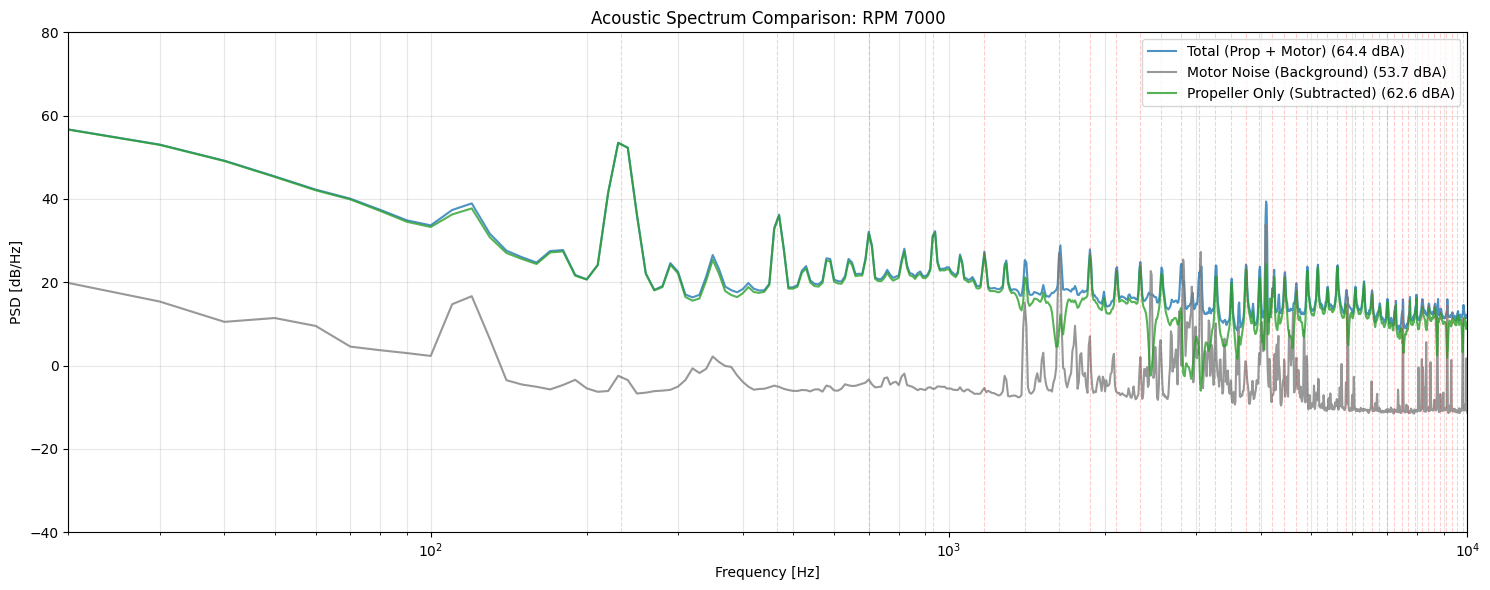

In [123]:
# Ensure lengths match
n = min(len(p_total), len(p_motor))
t_total, t_motor = t_total[:n], t_motor[:n]
p_total, p_motor = p_total[:n], p_motor[:n]

# 2. Perform Subtraction (Briefly re-calculated here for the plot)
f_stft, t_stft, Z_total = signal.stft(p_total, fs=fs, nperseg=2048)
_, _, Z_motor = signal.stft(p_motor, fs=fs, nperseg=2048)
mag_motor_avg = np.mean(np.abs(Z_motor), axis=1, keepdims=True)
mag_prop = np.maximum(np.abs(Z_total) - 2.0 * mag_motor_avg, 0.01 * mag_motor_avg)
t_prop_only, p_prop_only = signal.istft(mag_prop * np.exp(1j * np.angle(Z_total)), fs=fs)

# 3. Calculate OASPL (dBA)
oaspl_total = calculate_OASPL(t_total, p_total, propeller.acoustic_params.p_ref)
oaspl_motor = calculate_OASPL(t_motor, p_motor, propeller.acoustic_params.p_ref)
oaspl_prop = calculate_OASPL(t_prop_only, p_prop_only, propeller.acoustic_params.p_ref)

# 4. Plotting
fig, ax_spl = plt.subplots(figsize=(15, 6))

def plot_psd(ax, p_sig, fs, label_name, dba_val, color):
    # nperseg=fs/delta_f ensures we hit your 5Hz resolution target
    f_psd, pxx = signal.welch(p_sig, fs, window='hann', nperseg=int(fs/delta_f), scaling='density')
    psd_db = 10 * np.log10(pxx / (p_ref**2))
    ax.semilogx(f_psd, psd_db, label=f'{label_name} ({dba_val:.1f} dBA)', color=color, alpha=0.8)

plot_psd(ax_spl, p_total, fs, 'Total (Prop + Motor)', oaspl_total, 'tab:blue')
plot_psd(ax_spl, p_motor, fs, 'Motor Noise (Background)', oaspl_motor, 'tab:gray')
plot_psd(ax_spl, p_prop_only, fs, 'Propeller Only (Subtracted)', oaspl_prop, 'tab:green')

# BPF Harmonics (RPM 7000, assuming 2 blades)
bpf = (7000 / 60) * 2
for h in np.arange(bpf, 10000, bpf):
    ax_spl.axvline(h, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

# Styling
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('PSD [dB/Hz]', fontsize=fontsize)
ax_spl.set_xlim(20, 10000)
ax_spl.set_ylim(-40, 80)
ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='upper right')
plt.title('Acoustic Spectrum Comparison: RPM 7000', fontsize=fontsize+2)
plt.tight_layout()
plt.show()

In [124]:
signal = pf.Signal(p_prop_only, fs_total, fft_norm='rms')
meas_frequencies = signal.frequencies
meas_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.acoustic_params.p_ref).squeeze()

exp_spl_3oct = []
for fc in third_octave_freqs:
    f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
    mask = (meas_frequencies >= f_low) & (meas_frequencies < f_high)
    if np.any(mask):
        P_band = np.sum(10**(meas_spl[mask] / 10))
        exp_spl_3oct.append(10 * np.log10(P_band))
    else:
        exp_spl_3oct.append(-np.inf)

exp_spl_3oct = np.array(exp_spl_3oct)

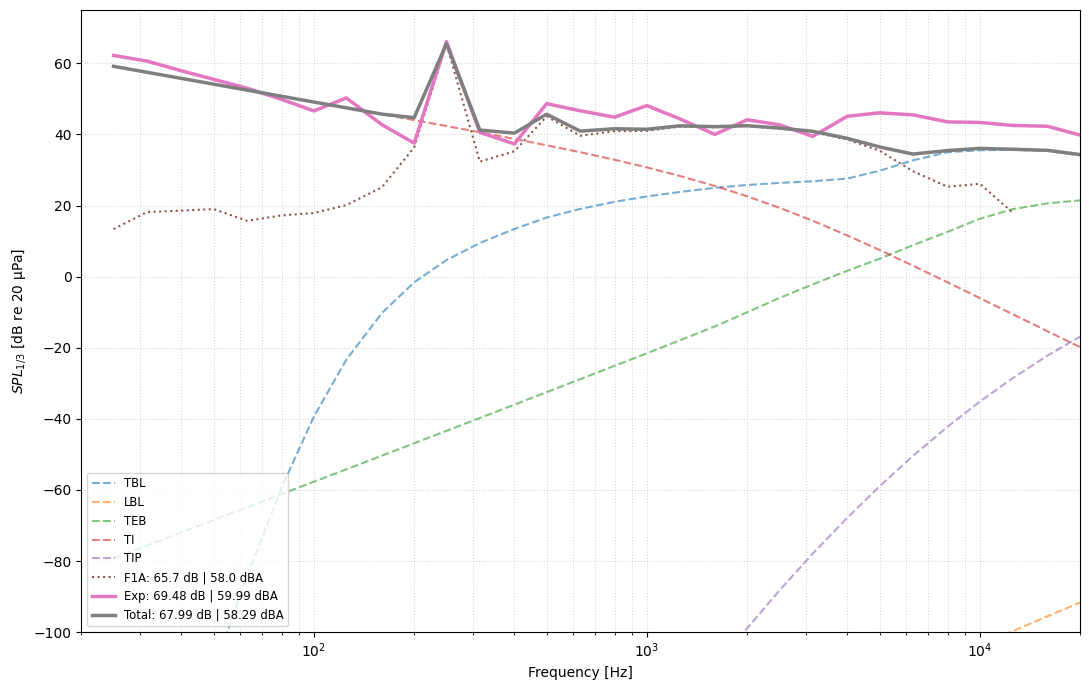

In [125]:
# Values for labels
ospl_f1a = calc_oaspl(F1A_spl_3oct, third_octave_freqs, weighted=False)
oaspl_f1a = calc_oaspl(F1A_spl_3oct, third_octave_freqs, weighted=True)

ospl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=False)
oaspl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=True)

ospl_tot = calc_oaspl(L_total, third_octave_freqs, weighted=False)
oaspl_tot = calc_oaspl(L_total, third_octave_freqs, weighted=True)

plt.figure(figsize=(11, 7))

plt.semilogx(third_octave_freqs, bpm.SPL_TBL, '--', alpha=0.6, label='TBL')
plt.semilogx(third_octave_freqs, bpm.SPL_LBL, '--', alpha=0.6, label='LBL')
plt.semilogx(third_octave_freqs, bpm.SPL_TEB, '--', alpha=0.6, label='TEB')
plt.semilogx(third_octave_freqs, bpm.SPL_TI, '--', alpha=0.6, label='TI')
plt.semilogx(third_octave_freqs, bpm.SPL_TIP, '--', alpha=0.6, label='TIP')
plt.semilogx(third_octave_freqs, F1A_spl_3oct, ':', label=f'F1A: {ospl_f1a:.1f} dB | {oaspl_f1a:.1f} dBA')

# Main Comparison Lines
plt.semilogx(third_octave_freqs, exp_spl_3oct, '-', linewidth=2.5, 
             label=f'Exp: {ospl_exp:.2f} dB | {oaspl_exp:.2f} dBA')
plt.semilogx(third_octave_freqs, L_total, '-', linewidth=2.5, 
             label=f'Total: {ospl_tot:.2f} dB | {oaspl_tot:.2f} dBA')

plt.xlabel('Frequency [Hz]')
plt.ylabel('$SPL_{1/3}$ [dB re 20 µPa]')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend(loc='lower left', fontsize='small', frameon=True)
plt.xlim(20, 20000)
plt.ylim(-100, 75)
plt.tight_layout()
plt.show()